# 5 · NDWI

On page 3, we tagged each Landsat pass with a tide height. This page picks two **clear-sky**
scenes from the tagging at opposite tides and makes the wet/dry contrast **quantitative** using the
**Normalised Difference Water Index (NDWI)**.

**What this notebook answers**

1. What is NDWI, and why does it separate water from sediment?
2. How does NDWI **change** between a low-tide and high-tide Landsat scene?
3. How does that logic scale to an **elevation map** on page 6?

**The core idea**

> For each pixel, find the tide height where the surface switches from dry to wet —
> that crossover height **is** the sediment elevation.

The next step will actually run the full NDWI algorithm across many scenes for each individual image, and can make an elevation map. However, here we build the **intuition** with just two clear-sky images.

**Previous:** [4 · Validation](04_validation.ipynb) (optional) · **Next:** [6 · Elevation](06_elevation.ipynb)

## Step 1 — Imports

In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import pystac_client
import planetary_computer as pc
import odc.stac

# cache_utils provides the scene catalogue from page 3 and a helper for
# fetching the matching STAC items from Planetary Computer.
from cache_utils import load_or_compute_scenes, fetch_stac_items_for_scenes

warnings.filterwarnings("ignore")

# All saved figures go into outputs/
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Imports OK.")

Imports OK.


## Step 2 — Configuration

Use the **same coordinates and window** as pages 3–4. We limit to Landsat 8/9 here
because page 6 also uses Landsat, so the visual intuition carries over directly.

| Variable | Role |
|---|---|
| `MAX_CLOUD` | Scene-level ceiling (%). Keep this **tight** (≤ 15%) so the RGB maps look clean. |
| `LOW_PCT` / `HIGH_PCT` | Percentile threshold for selecting the extreme-tide scenes. |
| `NDWI_WET` | NDWI threshold above which a pixel is called "wet" in the overlay. 0.0 is the standard starting point. |
| `DELTA` | Half-width of the bounding box around the site point (degrees). |

> If Step 3 finds fewer than 2 usable scenes, raise `MAX_CLOUD` slightly or extend
> the window. The algorithm needs at least one clear low-tide and one clear high-tide
> pass to make the comparison meaningful.

In [2]:
# === EDIT THESE ===
LON       = 4.81050
LAT       = 52.98886
SITE_NAME = "WaddenSea"

DELTA     = 0.08       # bounding-box half-width in degrees (~8 km)
START     = "2023-01-01"
END       = "2023-12-31"

TIDE_DIR  = "./tide_models"
TIDE_MODEL = "FES2022"

LOW_PCT   = 15         # use scenes in the lowest X% of tide heights
HIGH_PCT  = 15         # use scenes in the highest X% of tide heights
MAX_CLOUD = 15         # tight cloud ceiling for clean visuals
NDWI_WET  = 0.0        # NDWI > this = wet (standard threshold)

OVERWRITE_SCENES = False  # set True if you change site, dates, or sensors

# Derived settings used throughout the notebook
os.environ["EO_TIDES_TIDE_MODELS"] = TIDE_DIR
BBOX   = (LON - DELTA, LAT - DELTA, LON + DELTA, LAT + DELTA)
PC_URL = "https://planetarycomputer.microsoft.com/api/stac/v1"

print(f"Site   : {SITE_NAME}  ({LAT:.4f} N, {LON:.4f} E)")
print(f"Window : {START} to {END}")
print(f"Cloud  : scenes with eo:cloud_cover < {MAX_CLOUD}% only")

Site   : WaddenSea  (52.9889 N, 4.8105 E)
Window : 2023-01-01 to 2023-12-31
Cloud  : scenes with eo:cloud_cover < 15% only


## Step 3 — Select low- and high-tide scenes

We reuse the **scene cache from page 3** (Landsat 8/9), keeping only passes with
cloud cover below `MAX_CLOUD`. From those, we pick one representative scene per
tidal class:

- **Low-tide class** — scenes with tide height ≤ the `LOW_PCT` percentile.
- **High-tide class** — scenes with tide height ≥ the `1 − HIGH_PCT` percentile.

Within each class we pick the **clearest scene first** (lowest cloud cover),
using tide proximity as a tiebreaker. This gives us the best-quality image that
still represents a genuinely extreme tide.

In [3]:
# Load the cached scene catalogue (runs FES2022 tagging only if not cached)
scenes_df = load_or_compute_scenes(
    lon=LON, lat=LAT,
    start=START, end=END,
    site_name=SITE_NAME,
    tide_model=TIDE_MODEL,
    tide_dir=TIDE_DIR,
    max_cloud=MAX_CLOUD,
    delta=DELTA,
    overwrite=OVERWRITE_SCENES,
    sensors=["Landsat 8", "Landsat 9"],
)

# Ensure 'time' is a column (cache may return it as index)
if "time" not in scenes_df.columns:
    scenes_df = scenes_df.reset_index()

# Apply cloud and validity filters
usable = scenes_df[
    scenes_df["sensor"].isin(["Landsat 8", "Landsat 9"]) &
    (scenes_df["cloud_cover"].fillna(100) < MAX_CLOUD) &
    scenes_df["tide_height"].notna()
].copy()

if len(usable) < 2:
    raise SystemExit(
        f"Need ≥2 Landsat scenes with cloud < {MAX_CLOUD}% — "
        "try extending END, raising MAX_CLOUD, or setting OVERWRITE_SCENES=True."
    )


def pick_clearest(candidates: pd.DataFrame, tide_target: float) -> pd.DataFrame:
    """Return the single clearest scene; break ties by proximity to tide_target."""
    c = candidates.copy()
    c["_cloud"] = c["cloud_cover"].fillna(100)
    c["_tdist"] = (c["tide_height"] - tide_target).abs()
    return c.sort_values(["_cloud", "_tdist"]).iloc[:1].drop(columns=["_cloud", "_tdist"])


# Compute percentile thresholds from the usable scenes
low_thresh  = usable["tide_height"].quantile(LOW_PCT / 100)
high_thresh = usable["tide_height"].quantile(1 - HIGH_PCT / 100)

low_scenes  = usable[usable["tide_height"] <= low_thresh]
high_scenes = usable[usable["tide_height"] >= high_thresh]

if low_scenes.empty or high_scenes.empty:
    raise SystemExit(
        "Need both low- and high-tide scenes — adjust LOW_PCT / HIGH_PCT or extend END."
    )

low_pick  = pick_clearest(low_scenes,  low_thresh)
high_pick = pick_clearest(high_scenes, high_thresh)

print(f"Usable Landsat scenes (cloud < {MAX_CLOUD}%): {len(usable)}")
print(
    f"Low-tide pick  : {low_pick['time'].iloc[0]}  "
    f"({low_pick['tide_height'].iloc[0]:+.2f} m,  "
    f"cloud {low_pick['cloud_cover'].iloc[0]:.0f}%)"
)
print(
    f"High-tide pick : {high_pick['time'].iloc[0]}  "
    f"({high_pick['tide_height'].iloc[0]:+.2f} m,  "
    f"cloud {high_pick['cloud_cover'].iloc[0]:.0f}%)"
)

  Loaded from cache ← cache/scenes_WaddenSea_l8-l9_2023-01-01_2023-12-31.parquet  (55 rows)
Usable Landsat scenes (cloud < 15%): 14
Low-tide pick  : 2023-04-03 10:33:11.673709+00:00  (-0.74 m,  cloud 0%)
High-tide pick : 2023-07-07 10:39:11.446066+00:00  (+0.94 m,  cloud 0%)


## Step 4 — What is NDWI?

NDWI compares **green** and **near-infrared (NIR)** reflectance:

$$
\mathrm{NDWI} = \frac{\rho_{\mathrm{green}} - \rho_{\mathrm{NIR}}}
                     {\rho_{\mathrm{green}} + \rho_{\mathrm{NIR}}}
$$

The physics: **liquid water absorbs near-infrared strongly**, while dry sediment and
vegetation reflect it. Dividing by the sum normalises for illumination differences
between scenes.

| Surface | Green | NIR | NDWI |
|---|---|---|---|
| **Open water** | moderate | very low (absorbed) | **positive** |
| **Dry sediment** | moderate | higher | **negative** |
| **Vegetated marsh** | moderate | high | negative |

On an intertidal flat, the *same pixel* moves along this scale as the tide rises:
dry at low water (NDWI < 0) → wet at high water (NDWI > 0).

**Why not just use RGB?** True-colour images are intuitive but subjective and
vary with sun angle and atmosphere. NDWI gives a single, calibrated number per
pixel that can relate to a **modelled tide height** — the bridge from colour to metres above sea level.

> **Note:** Page 6 uses the continuous NDWI signal, not a hard threshold. The binary
> wet mask in Step 6 (NDWI > `NDWI_WET`) is for visual guidance only.

## Step 5 — Load Landsat and compute NDWI

For each selected scene we:

1. Query Planetary Computer for the matching STAC item.
2. Load `green`, `nir08`, `red`, `blue`, and `qa_pixel` at 30 m via `odc.stac`.
3. Apply the **Landsat Collection 2 cloud mask** (QA bits 3 = cloud, 4 = shadow).
4. Apply the **USGS surface-reflectance scale** (`DN × 0.0000275 − 0.2`).
5. Compute NDWI from the scaled green and NIR bands.

In [4]:
# Open the Planetary Computer STAC catalogue (sign_inplace adds tokens automatically)
catalog = pystac_client.Client.open(PC_URL, modifier=pc.sign_inplace)


def load_landsat_ndwi(scenes: pd.DataFrame, label: str) -> xr.Dataset:
    # Fetch the STAC items that match the selected scene rows
    items = fetch_stac_items_for_scenes(catalog, scenes, BBOX)
    if not items:
        raise ValueError(f"No STAC items found for {label}")

    print(f"  {label}: {len(items)} STAC item(s) — downloading pixels ...")

    # Load all requested bands into memory (compute() triggers the Dask graph)
    ds = odc.stac.load(
        items,
        bands=["red", "green", "blue", "nir08", "qa_pixel"],
        bbox=BBOX,
        crs="utm",
        resolution=30,                       # Landsat native resolution
        groupby="time",
        chunks={"x": 1024, "y": 1024},       # Dask chunk size for memory management
        resampling={"qa_pixel": "nearest", "*": "cubic"},
        patch_url=pc.sign,
    ).compute()

    # Cloud and shadow mask: QA bit 3 = cloud, bit 4 = shadow
    # We keep only pixels where BOTH flags are zero (i.e. clear)
    qa    = ds["qa_pixel"]
    clear = np.bitwise_and(qa, (1 << 3) | (1 << 4)) == 0
    ds    = ds.where(clear).drop_vars("qa_pixel")

    # Convert Collection 2 Level-2 scaled integers to surface reflectance (0–1)
    for band in ("red", "green", "blue", "nir08"):
        ds[band] = (ds[band] * 0.0000275 - 0.2).clip(0, 1)

    # Compute NDWI from the calibrated green and NIR bands
    ds["ndwi"] = (ds.green - ds.nir08) / (ds.green + ds.nir08)
    return ds


print("Loading low-tide scene ...")
ds_low  = load_landsat_ndwi(low_pick,  "low tide")
print("Loading high-tide scene ...")
ds_high = load_landsat_ndwi(high_pick, "high tide")
print("Done.")

Loading low-tide scene ...
  low tide: 1 STAC item(s) — downloading pixels ...
Loading high-tide scene ...
  high tide: 1 STAC item(s) — downloading pixels ...
Done.


## Step 6 — Compare NDWI at low vs high tide

Each row shows one tidal state across three columns:

| Column | What it shows |
|---|---|
| **RGB** | True-colour view — intuitive but not quantitative |
| **NDWI map** | Continuous index: blue = wet (positive), brown = dry (negative) |
| **Wet mask** | Binary: pixels where NDWI > `NDWI_WET` |

The intertidal zone is the area that **flips** from brown to blue between the two rows.
Permanent water stays blue in both; land stays brown in both.

> **If the two rows look identical:** the tide contrast between the selected scenes
> is too small. Widen `LOW_PCT` / `HIGH_PCT`, extend `END`, or check the tide tags
> from page 3.

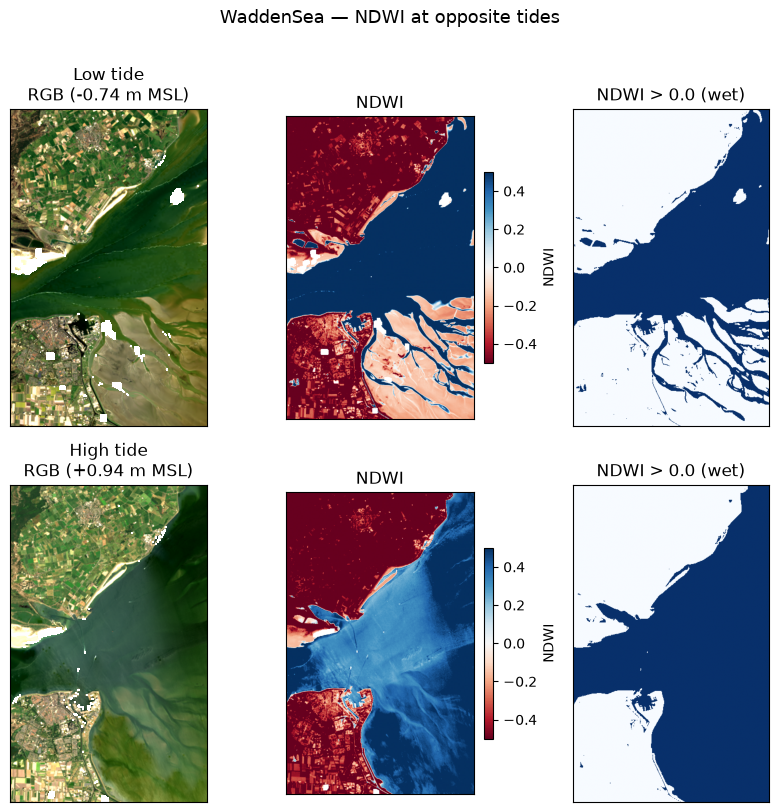

Saved: outputs/WaddenSea_ndwi_low_high.png


In [7]:
def _percentile_stretch(red, green, blue, pct=(2, 98)):
    # Stretch RGB bands to [0, 1] using percentile clipping for display.
    # This corrects for atmospheric haze and improves contrast.
    stacked = xr.concat([red, green, blue], dim="band")
    lo, hi  = np.nanpercentile(stacked.values, pct)
    rgb = np.clip(stacked.values, lo, hi)
    rgb = (rgb - lo) / (hi - lo + 1e-9)   # normalise to [0, 1]
    return np.moveaxis(rgb, 0, -1)          # rearrange to (y, x, 3) for imshow


def plot_ndwi_pair(ds_lo, ds_hi, tide_lo, tide_hi):
    fig, axes = plt.subplots(2, 3, figsize=(8, 8))

    for row, (ds, tide, title) in enumerate([
        (ds_lo, tide_lo, "Low tide"),
        (ds_hi, tide_hi, "High tide"),
    ]):
        # Handle datasets with a time dimension (single time step)
        t = 0 if ds.sizes.get("time", 1) == 1 else slice(None)
        red, green, blue = (
            ds.red.isel(time=t),
            ds.green.isel(time=t),
            ds.blue.isel(time=t),
        )
        ndwi = ds.ndwi.isel(time=t)
        wet  = ndwi > NDWI_WET   # binary wet mask

        # Column 1: true-colour RGB
        rgb = _percentile_stretch(red, green, blue)
        axes[row, 0].imshow(rgb)
        axes[row, 0].set_title(f"{title}\nRGB ({tide:+.2f} m MSL)")

        # Column 2: NDWI — diverging colourmap centred on zero
        im = axes[row, 1].imshow(ndwi.values, cmap="RdBu", vmin=-0.5, vmax=0.5)
        axes[row, 1].set_title("NDWI")
        plt.colorbar(im, ax=axes[row, 1], fraction=0.046, label="NDWI")

        # Column 3: binary wet mask
        axes[row, 2].imshow(wet.values, cmap="Blues", vmin=0, vmax=1)
        axes[row, 2].set_title(f"NDWI > {NDWI_WET} (wet)")

        for ax in axes[row]:
            ax.set_aspect("equal")
            ax.set_xticks([]); ax.set_yticks([])

    fig.suptitle(f"{SITE_NAME} — NDWI at opposite tides", fontsize=13, y=1.01)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"{SITE_NAME}_ndwi_low_high.png",
                dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: outputs/{SITE_NAME}_ndwi_low_high.png")


plot_ndwi_pair(
    ds_low,  ds_high,
    float(low_pick["tide_height"].iloc[0]),
    float(high_pick["tide_height"].iloc[0]),
)

> **Reading the maps:**
>
> | What you see | Meaning |
> |---|---|
> | Flat **dry at low tide, wet at high** | NDWI working — these pixels carry elevation information |
> | Channel **always wet** | Permanent water — no crossover → no intertidal elevation |
> | Land **always dry** | Never floods → outside the intertidal zone |
> | Maps look **hazy or patchy** | Tighten `MAX_CLOUD` or extend `END` for clearer scenes |

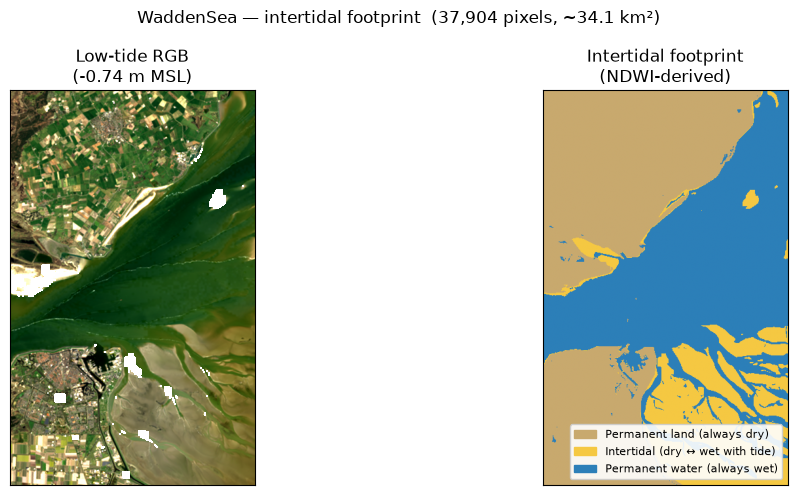

Saved: outputs/WaddenSea_intertidal_footprint.png
Intertidal pixels : 37,904  (~34.11 km²)
Permanent water   : 88,316
Permanent land    : 98,470


In [8]:
## Step 6b — Intertidal footprint

# The intertidal zone is, by definition, what changes between the two tidal states:
# pixels that were DRY at low tide and WET at high tide.
# Everything else is either permanently submerged (always wet) or permanent land (always dry).

t_lo = 0 if ds_low.sizes.get("time", 1) == 1 else slice(None)
t_hi = 0 if ds_high.sizes.get("time", 1) == 1 else slice(None)

ndwi_low  = ds_low.ndwi.isel(time=t_lo)
ndwi_high = ds_high.ndwi.isel(time=t_hi)

# Binary masks: True where the pixel is wet at that tidal state
wet_low  = ndwi_low  > NDWI_WET
wet_high = ndwi_high > NDWI_WET

# Intertidal = dry at low tide AND wet at high tide
intertidal = (~wet_low) & wet_high

# For context: permanent water and permanent land
permanent_water = wet_low  & wet_high   # always wet
permanent_land  = (~wet_low) & (~wet_high)  # always dry

# Build a 3-class map: 0 = land, 1 = intertidal, 2 = water
class_map = np.zeros(intertidal.shape, dtype=np.uint8)
class_map[permanent_water.values]  = 2
class_map[intertidal.values]       = 1
# permanent_land stays 0

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: RGB of low-tide scene for spatial context
rgb_lo = _percentile_stretch(
    ds_low.red.isel(time=t_lo),
    ds_low.green.isel(time=t_lo),
    ds_low.blue.isel(time=t_lo),
)
axes[0].imshow(rgb_lo)
axes[0].set_title(f"Low-tide RGB\n({low_pick['tide_height'].iloc[0]:+.2f} m MSL)")

# Right: 3-class intertidal map
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

cmap = ListedColormap(["#c8a96e", "#f5c842", "#2c7fb8"])  # land / intertidal / water
axes[1].imshow(class_map, cmap=cmap, vmin=0, vmax=2)
axes[1].set_title("Intertidal footprint\n(NDWI-derived)")

legend = [
    Patch(color="#c8a96e", label="Permanent land (always dry)"),
    Patch(color="#f5c842", label="Intertidal (dry ↔ wet with tide)"),
    Patch(color="#2c7fb8", label="Permanent water (always wet)"),
]
axes[1].legend(handles=legend, loc="lower right", fontsize=8, framealpha=0.9)

for ax in axes:
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])

n_inter = int(intertidal.values.sum())
area_km2 = n_inter * (30 ** 2) / 1e6   # Landsat pixel = 30 × 30 m
fig.suptitle(
    f"{SITE_NAME} — intertidal footprint  "
    f"({n_inter:,} pixels, ~{area_km2:.1f} km²)",
    fontsize=12,
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / f"{SITE_NAME}_intertidal_footprint.png",
            dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved: outputs/{SITE_NAME}_intertidal_footprint.png")
print(f"Intertidal pixels : {n_inter:,}  (~{area_km2:.2f} km²)")
print(f"Permanent water   : {int(permanent_water.values.sum()):,}")
print(f"Permanent land    : {int(permanent_land.values.sum()):,}")

## Step 7 — From NDWI to elevation

For a **single intertidal pixel**, imagine plotting NDWI against tide height for every
clear Landsat overpass across several years:

```
NDWI
  +1 │     ●  ●      ← wet observations (high tide)
     │   ●
   0 │ - - - - - - - ← crossover (waterline = elevation)
     │ ●
  -1 │●  ●           ← dry observations (low tide)
     └──────────────── tide height (m, MSL)
                    ↑
              elevation estimate
```

`intertidal.elevation()` on page 6 does this for **every pixel**:

1. Builds a multi-year NDWI time series from all clear Landsat scenes.
2. Tags each observation with the FES2022 tide height at that moment.
3. Fits the **crossover tide level** and estimates an uncertainty per pixel.
4. Outputs an **elevation surface** (m, MSL) and QA layers.

You have already validated the tide tags (pages 3–4) and confirmed the wet/dry
contrast exists in real imagery (this page). Page 6 is the production run.

## Step 8 — Summary

In this notebook you built the visual intuition for the elevation method:

1. **NDWI formula (Step 4)** — green vs NIR separates water from dry sediment using
   calibrated surface reflectance. A single, scene-independent number per pixel.
2. **Low vs high maps (Step 6)** — the same intertidal flat shifts from negative
   to positive NDWI as the tide rises. Permanent water and dry land do not shift.

**Checklist before page 6**

| Check | Where to verify |
|---|---|
| Enough Landsat scenes over several years | Page 3 — TOT ≥ 0.8, n ≥ 20 |
| FES2022 trustworthy at your site | Page 4 — MAE < 20 cm |
| Visible wet/dry contrast in the maps | This page — Step 6 |

**Next:** [6 · Elevation →](06_elevation.ipynb)